In [1]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================================

# pandas is used for:
# - Reading the CSV file
# - Data cleaning
# - Data manipulation
# - Creating summary tables

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scipy.stats is used for statistical tests such as:
# - ANOVA
# - t-test
# - correlation-related statistical analysis

from scipy import stats

# Display all columns when we print a DataFrame
pd.set_option("display.max_columns", None)

# Display numerical values with 2 decimal places
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:

# CELL 2: UPLOAD DATASET

from google.colab import files
uploaded = files.upload()
print("Uploaded file:")
print(list(uploaded.keys()))

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Uploaded file:
['seasonal_agriculture_performance_dataset.csv']


In [3]:

# CELL 3: LOAD THE DATASET
# Name of our CSV file
file_name = "seasonal_agriculture_performance_dataset.csv"

# Read the CSV file using pandas
df = pd.read_csv(file_name)

# Display a message confirming that the dataset was loaded
print("Dataset loaded successfully!")

# Display number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display first 5 rows
display(df.head())

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [4]:
#CELL 4: DISPLAY FIRST 10 ROWS
# head(10) displays the first 10 records
display(df.head(10))

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30
5,SF10006,Gujarat,Raichur,Pulses,Zaid,5.46,356.00,33.60,49.00,8.30,6.93,11.40,105.10,34.70,78.70,Rainfed,58.80,4.48,0.89,0.72,3.93,68593,302333,269570,-32763,1093,3.60,57.10
6,SF10007,Telangana,Warangal,Wheat,Rabi,8.13,432.20,23.50,50.80,9.50,6.96,24.70,115.80,69.40,109.80,Rainfed,181.60,7.99,0.87,2.53,20.57,22951,513341,472102,-41239,2368,8.69,31.60
7,SF10008,Tamil Nadu,Ludhiana,Pulses,Kharif,5.34,860.20,29.00,64.90,7.90,6.09,36.90,112.70,60.90,115.90,Sprinkler,245.80,5.89,0.70,1.18,6.30,70042,436200,441265,5065,1704,3.70,54.20
8,SF10009,Karnataka,Guntur,Cotton,Zaid,6.98,624.70,33.40,46.80,7.90,6.41,12.30,66.90,47.60,134.20,Sprinkler,190.70,2.21,0.88,1.53,10.68,70771,525129,755834,230705,5079,2.10,54.70
9,SF10010,Tamil Nadu,Raichur,Chilli,Rabi,13.69,415.80,22.30,57.30,8.60,6.60,23.30,117.90,37.20,116.60,Drip,168.80,7.29,0.70,2.29,31.35,94383,1004072,2958907,1954835,5984,5.24,41.70


In [18]:
#CELL 5: DISPLAY LAST 10 ROWS
# tail(10) displays the last 10 records
display(df.tail(10))

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3990,SF13991,Tamil Nadu,Indore,Cotton,Kharif,6.58,"1,072.30",28.00,79.60,7.30,6.46,29.40,121.30,45.40,64.00,Flood,70.70,6.71,0.70,1.62,10.66,72931,388777,777444,388667,6259,1.70,41.10
3991,SF13992,Telangana,Rajkot,Chilli,Zaid,2.04,338.80,34.40,69.00,7.50,6.29,14.70,61.50,56.30,80.70,Drip,173.80,4.68,0.82,1.07,2.18,80847,137231,176246,39015,854,2.55,41.80
3992,SF13993,Karnataka,Rajkot,Groundnut,Rabi,2.03,579.90,20.40,56.50,8.00,6.36,26.40,141.10,55.70,102.40,Flood,203.10,5.77,0.66,1.61,3.27,58117,139340,190043,50703,1416,2.31,38.60
3993,SF13994,Gujarat,Rajkot,Cotton,Rabi,13.48,308.90,25.00,70.80,8.10,6.31,26.30,86.10,40.40,107.80,Sprinkler,164.10,3.91,0.89,1.33,17.93,71268,1053465,1277835,224370,10589,1.69,43.70
3994,SF13995,Maharashtra,Ludhiana,Wheat,Kharif,9.20,"1,243.80",27.50,66.50,7.40,7.11,25.40,102.30,49.20,95.40,Flood,263.30,2.59,0.70,2.18,20.06,23314,618838,467679,-151159,5577,3.60,67.10
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [8]:
# CELL 6: CHECK DATASET SHAPE
# Shape returns:
# First value  -> number of rows
# Second value -> number of columns

rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)


Number of rows: 4000
Number of columns: 28


In [9]:
# CELL 7: DISPLAY COLUMN NAMES
# columns.tolist() converts column names into a Python list

print("Columns present in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, "->", column)

Columns present in the dataset:

1 -> Farm_ID
2 -> State
3 -> District
4 -> Crop
5 -> Season
6 -> Farm_Area_Hectares
7 -> Rainfall_mm
8 -> Avg_Temperature_C
9 -> Humidity_pct
10 -> Sunlight_Hours_Day
11 -> Soil_pH
12 -> Soil_Moisture_pct
13 -> Nitrogen_kg_ha
14 -> Phosphorus_kg_ha
15 -> Potassium_kg_ha
16 -> Irrigation_Method
17 -> Fertilizer_kg_ha
18 -> Pesticide_Litre_ha
19 -> Seed_Quality_Score
20 -> Yield_Tonnes_Ha
21 -> Production_Tonnes
22 -> Market_Price_INR_Tonne
23 -> Total_Cost_INR
24 -> Revenue_INR
25 -> Profit_INR
26 -> Water_Used_m3
27 -> Water_Efficiency_t_per_1000m3
28 -> Disease_Pest_Risk_pct


In [10]:
#CELL 8:DATASET INFO
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [11]:
# CELL 9: DESCRIPTIVE STATISTICS

# describe() calculates:
# - Count
# - Mean
# - Standard deviation
# - Minimum
# - 25th percentile
# - Median
# - 75th percentile
# - Maximum

display(df.describe())


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [12]:

# CELL 10: CHECK MISSING VALUES

# isnull().sum() counts missing values in every column

missing_values = df.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (df.isnull().mean() * 100)

# Create a table
missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

# Sort from highest missing values to lowest
missing_table = missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_table)

,Missing Values,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80
Farm_ID,0,0.00
Crop,0,0.00
District,0,0.00
Farm_Area_Hectares,0,0.00
Season,0,0.00
Avg_Temperature_C,0,0.00
Humidity_pct,0,0.00


In [13]:

# CELL 11: COLUMNS WITH MISSING VALUES

# Select only columns where missing values are greater than 0

missing_only = missing_table[
    missing_table["Missing Values"] > 0
]

display(missing_only)

,Missing Values,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [14]:

# CELL 12: CHECK DUPLICATE RECORDS

# duplicated() identifies repeated rows
# sum() counts how many duplicate rows exist

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [15]:

# CELL 13: IDENTIFY NUMERIC COLUMNS

# select_dtypes() selects columns containing numerical data

numeric_cols = df.select_dtypes(
    include=np.number
).columns

print("Numeric columns:")
print(list(numeric_cols))

Numeric columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [16]:

# CELL 14: IDENTIFY NUMERIC COLUMNS

# select_dtypes() selects columns containing numerical data

numeric_cols = df.select_dtypes(
    include=np.number
).columns

print("Numeric columns:")
print(list(numeric_cols))

Numeric columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [17]:

# CELL 15: HANDLE MISSING NUMERIC VALUES

# We use the MEDIAN to fill missing numerical values.
#
# Why median?
# Agricultural datasets may contain extreme values/outliers.
# Median is less affected by extreme values than the mean.

for column in numeric_cols:

    # Check whether the column has missing values
    if df[column].isnull().sum() > 0:

        # Calculate median
        median_value = df[column].median()

        # Replace missing values with median
        df[column] = df[column].fillna(median_value)

print("Missing numerical values have been handled.")

Missing numerical values have been handled.


In [19]:

# CELL 16: VERIFY MISSING VALUES AFTER CLEANING

# Count all missing values after cleaning

remaining_missing = df.isnull().sum().sum()

print("Total remaining missing values:", remaining_missing)

Total remaining missing values: 0


In [20]:

# CELL 17: SEASON DISTRIBUTION

# Count number of records belonging to each season

season_count = df["Season"].value_counts()

print("Number of records in each season:")
display(season_count.to_frame("Number of Records"))

Number of records in each season:


,Number of Records
Season,
Kharif,1779
Rabi,1627
Zaid,594


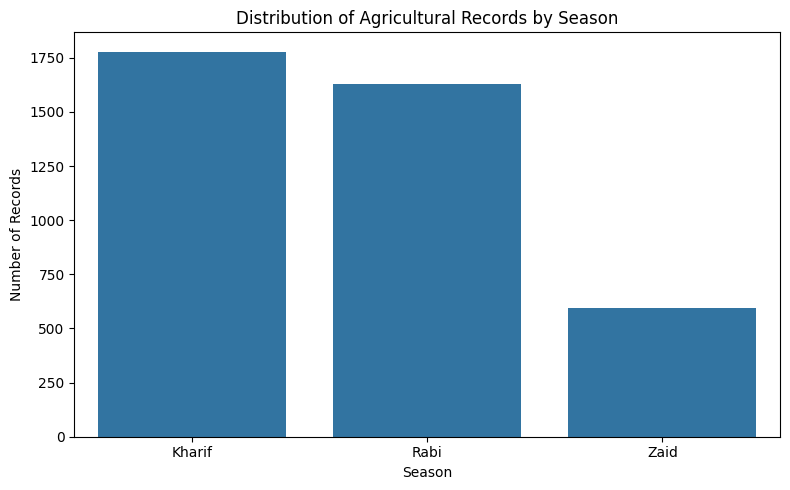

In [21]:

# CELL 18: VISUALIZE SEASON DISTRIBUTION

plt.figure(figsize=(8,5))

# Create a bar chart
sns.countplot(
    data=df,
    x="Season",
    order=season_count.index
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [22]:

# CELL 19: AVERAGE YIELD BY SEASON

# Group data according to season
# Then calculate average yield

yield_by_season = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Yield by Season:")
display(
    yield_by_season.to_frame(
        "Average Yield (Tonnes/Ha)"
    )
)

Average Yield by Season:


,Average Yield (Tonnes/Ha)
Season,
Kharif,5.63
Rabi,5.04
Zaid,4.64


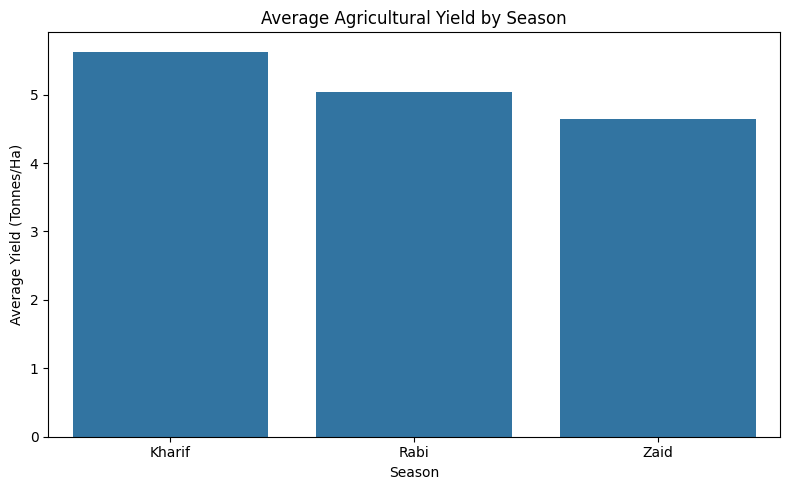

In [23]:
# ============================================================
# CELL 20: VISUALIZE AVERAGE YIELD BY SEASON
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=yield_by_season.index,
    y=yield_by_season.values
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [69]:
# CELL 21: INFO
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [24]:
# ============================================================
# CELL 22: AVERAGE PRODUCTION BY SEASON
# ============================================================

# We group the agricultural data according to Season.
# Then we calculate the average production for each season.
#
# Production_Tonnes represents the total agricultural
# production measured in tonnes.

production_by_season = (
    df.groupby("Season")["Production_Tonnes"]
    .mean()
    .sort_values(ascending=False)
)

# Display the result
print("Average Production by Season:")

display(
    production_by_season.to_frame(
        "Average Production (Tonnes)"
    )
)

Average Production by Season:


,Average Production (Tonnes)
Season,
Kharif,46.31
Rabi,41.49
Zaid,38.89


In [25]:
# ============================================================
# CELL 23: AVERAGE REVENUE BY SEASON
# ============================================================

# Revenue represents the amount of money generated
# from agricultural production.

# Group the data by Season and calculate average revenue.

revenue_by_season = (
    df.groupby("Season")["Revenue_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Revenue by Season:")

display(
    revenue_by_season.to_frame(
        "Average Revenue (INR)"
    )
)

Average Revenue by Season:


,Average Revenue (INR)
Season,
Kharif,"710,719.06"
Rabi,"601,526.05"
Zaid,"519,171.90"


In [26]:
# ============================================================
# CELL 24: AVERAGE PROFIT BY SEASON
# ============================================================

# Profit is an important economic performance indicator.
# We group the records according to Season and calculate
# the average profit for each season.

profit_by_season = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Profit by Season:")

display(
    profit_by_season.to_frame(
        "Average Profit (INR)"
    )
)

Average Profit by Season:


,Average Profit (INR)
Season,
Kharif,"178,914.65"
Rabi,"87,689.47"
Zaid,"-24,804.82"


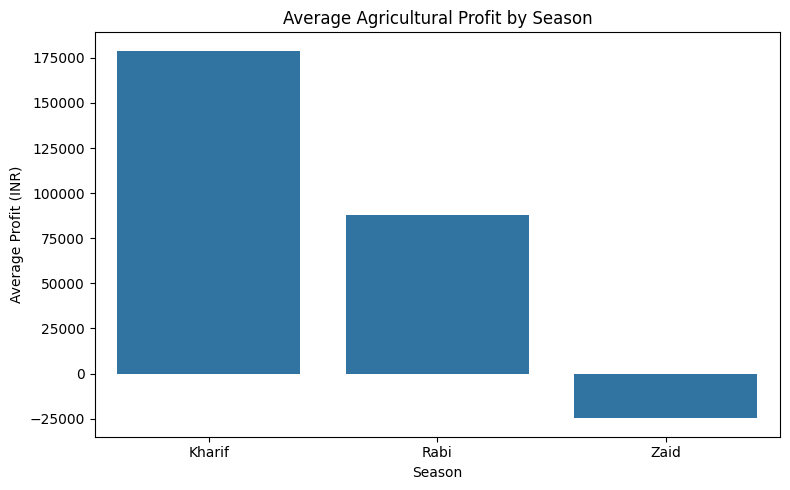

In [27]:
# ============================================================
# CELL 25: VISUALIZE AVERAGE PROFIT BY SEASON
# ============================================================

# Create a figure for the bar chart
plt.figure(figsize=(8, 5))

# Create bar chart using the season-wise profit values
sns.barplot(
    x=profit_by_season.index,
    y=profit_by_season.values
)

# Add title and axis labels
plt.title("Average Agricultural Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

# Display actual numbers instead of scientific notation
plt.ticklabel_format(
    style="plain",
    axis="y"
)

# Adjust spacing
plt.tight_layout()

# Display graph
plt.show()

In [28]:
# ============================================================
# CELL 26: COMPLETE SEASONAL PERFORMANCE SUMMARY
# ============================================================

# In this cell, we compare all major agricultural
# performance indicators across different seasons.
#
# We group the dataset by "Season" and calculate
# the average value of each important variable.

season_summary = df.groupby("Season").agg(

    # --------------------------------------------------------
    # NUMBER OF AGRICULTURAL RECORDS
    # --------------------------------------------------------
    # Counts how many records/farms are available
    # for each season.
    Farms=("Farm_ID", "count"),

    # --------------------------------------------------------
    # AGRICULTURAL PERFORMANCE
    # --------------------------------------------------------
    # Average crop yield in tonnes per hectare
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),

    # Average total production in tonnes
    Avg_Production=("Production_Tonnes", "mean"),

    # --------------------------------------------------------
    # ECONOMIC PERFORMANCE
    # --------------------------------------------------------
    # Average revenue generated
    Avg_Revenue=("Revenue_INR", "mean"),

    # Average cost of agricultural activities
    Avg_Cost=("Total_Cost_INR", "mean"),

    # Average profit
    Avg_Profit=("Profit_INR", "mean"),

    # --------------------------------------------------------
    # RESOURCE USAGE
    # --------------------------------------------------------
    # Average amount of water used
    Avg_Water_Used=("Water_Used_m3", "mean"),

    # Average agricultural output obtained
    # per 1000 cubic metres of water
    Avg_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    ),

    # --------------------------------------------------------
    # ENVIRONMENTAL CONDITIONS
    # --------------------------------------------------------
    # Average rainfall
    Avg_Rainfall=("Rainfall_mm", "mean"),

    # Average temperature
    Avg_Temperature=("Avg_Temperature_C", "mean"),

    # --------------------------------------------------------
    # AGRICULTURAL RISK
    # --------------------------------------------------------
    # Average disease and pest risk
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")

).round(2)

# Display the final seasonal summary table
display(season_summary)

,Farms,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Rainfall,Avg_Temperature,Avg_Disease_Risk
Season,,,,,,,,,,,
Kharif,1779,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,849.20,28.45,54.47
Rabi,1627,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,437.62,23.49,40.48
Zaid,594,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,304.65,31.04,38.22


                    SEASON
                       ↓
        ┌──────────────┼──────────────┐
        ↓              ↓              ↓
   PERFORMANCE     ECONOMICS       RESOURCES
        ↓              ↓              ↓
     Yield          Revenue       Water Used
     Production     Cost          Water Efficiency
                    Profit
                       ↓
                 ENVIRONMENT
                       ↓
              Rainfall/Temperature
                       ↓
                    RISK
                       ↓
               Disease/Pest Risk

In [29]:
# ============================================================
# CELL 27: ENVIRONMENTAL CONDITIONS BY SEASON
# ============================================================

# Environmental conditions can influence agricultural
# activities and crop performance.
#
# Here, we calculate the average environmental conditions
# for each season.

environmental_summary = df.groupby("Season")[

    [
        # Average rainfall received
        "Rainfall_mm",

        # Average temperature
        "Avg_Temperature_C",

        # Average humidity
        "Humidity_pct",

        # Average sunlight received per day
        "Sunlight_Hours_Day",

        # Average soil moisture
        "Soil_Moisture_pct"
    ]

].mean().round(2)

# Display the environmental summary
display(environmental_summary)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


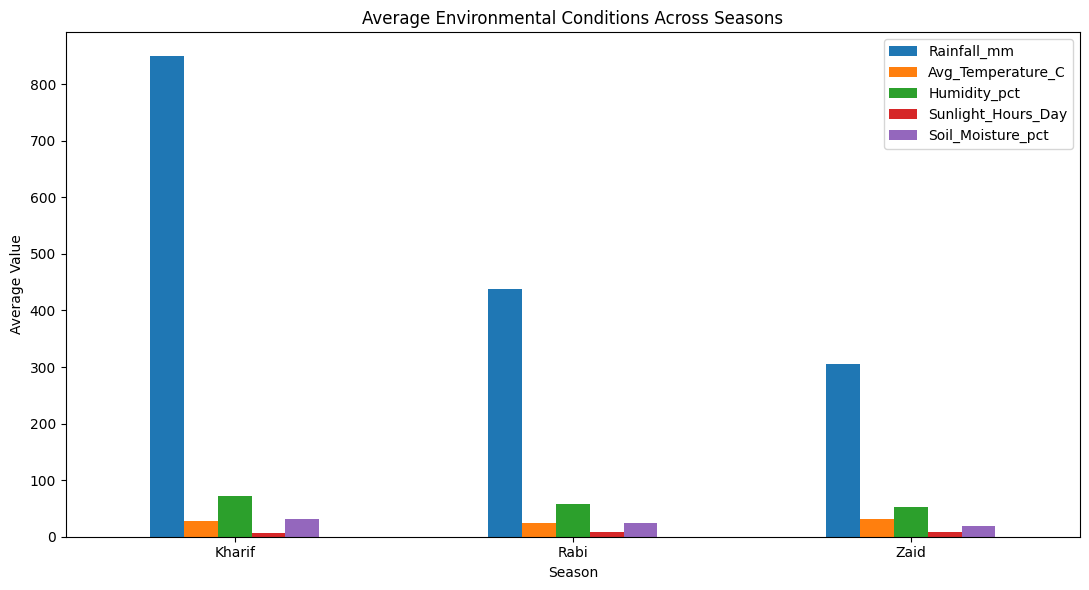

In [30]:
# ============================================================
# CELL 28: VISUALIZE ENVIRONMENTAL CONDITIONS
# ============================================================

# Convert the environmental summary into a bar chart.

environmental_summary.plot(
    kind="bar",
    figsize=(11, 6)
)

# Add title
plt.title(
    "Average Environmental Conditions Across Seasons"
)

# Add axis labels
plt.xlabel("Season")
plt.ylabel("Average Value")

# Keep season names horizontal
plt.xticks(rotation=0)

# Adjust layout
plt.tight_layout()

# Display the graph
plt.show()

In [31]:
# ============================================================
# CELL 29: RESOURCE USAGE BY SEASON
# ============================================================

# Agricultural production depends on different resources such as:
# - Nitrogen
# - Phosphorus
# - Potassium
# - Fertilizer
# - Pesticides
# - Water
#
# Here, we calculate the average usage of these resources
# for each agricultural season.

resource_summary = df.groupby("Season")[

    [
        # Nitrogen used per hectare
        "Nitrogen_kg_ha",

        # Phosphorus used per hectare
        "Phosphorus_kg_ha",

        # Potassium used per hectare
        "Potassium_kg_ha",

        # Total fertilizer used per hectare
        "Fertilizer_kg_ha",

        # Pesticide used per hectare
        "Pesticide_Litre_ha",

        # Water used in cubic metres
        "Water_Used_m3"
    ]

].mean().round(2)

# Display the resource usage summary
display(resource_summary)

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,"6,102.20"
Rabi,120.40,57.31,103.93,185.41,5.02,"5,846.99"
Zaid,120.53,58.13,105.42,184.64,5.17,"6,419.89"


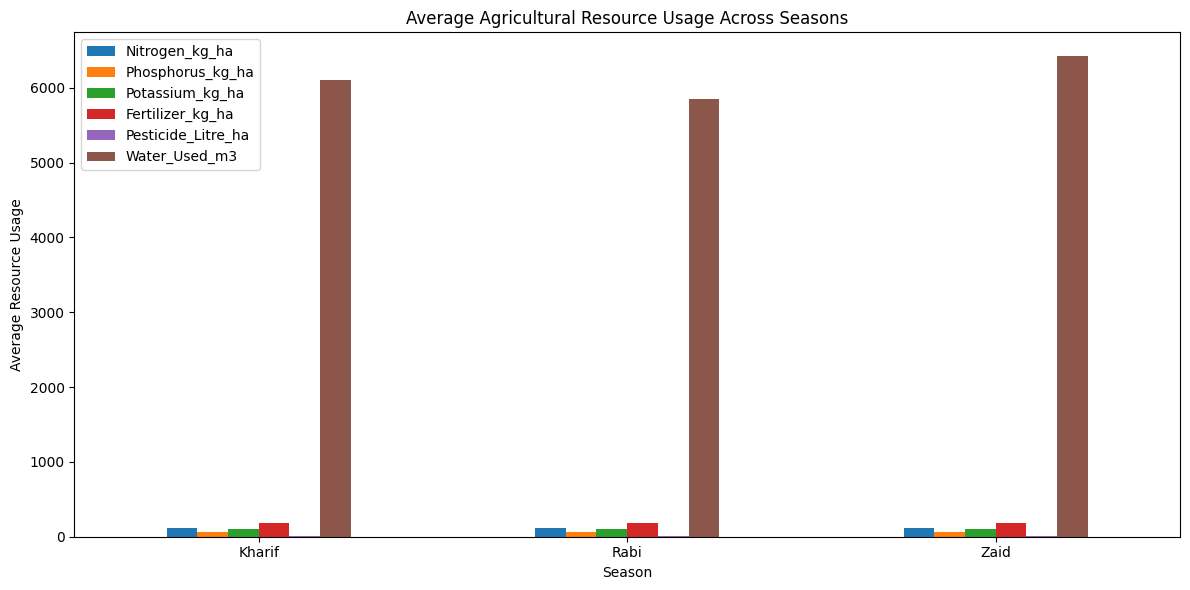

In [32]:
# ============================================================
# CELL 30: VISUALIZE RESOURCE USAGE
# ============================================================

# Convert the resource summary table into a bar chart.
#
# Each group of bars represents a season.
# Different bars represent different agricultural resources.

resource_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

# Add title
plt.title(
    "Average Agricultural Resource Usage Across Seasons"
)

# Add axis labels
plt.xlabel("Season")
plt.ylabel("Average Resource Usage")

# Keep season names horizontal
plt.xticks(rotation=0)

# Adjust the spacing so that labels don't overlap
plt.tight_layout()

# Display the graph
plt.show()

In [33]:
# ============================================================
# CELL 31: CROP-WISE AGRICULTURAL PERFORMANCE
# ============================================================

# Agriculture contains different crops.
# Here we compare the performance of each crop.

crop_summary = df.groupby("Crop").agg(

    # Number of records available for each crop
    Farms=("Farm_ID", "count"),

    # Average yield of the crop
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),

    # Average production
    Avg_Production=("Production_Tonnes", "mean"),

    # Average revenue
    Avg_Revenue=("Revenue_INR", "mean"),

    # Average profit
    Avg_Profit=("Profit_INR", "mean"),

    # Average disease and pest risk
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")

).sort_values(
    # Sort crops from highest to lowest average yield
    by="Avg_Yield",
    ascending=False
).round(2)

# Display crop-wise summary
display(crop_summary)

,Farms,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Profit,Avg_Disease_Risk
Crop,,,,,,
Sugarcane,305,46.64,392.41,"1,371,980.11","817,187.99",45.40
Maize,551,2.71,21.78,"457,067.99","-83,978.33",45.54
Rice,690,2.43,19.29,"423,615.26","-102,213.50",46.50
Wheat,614,2.11,16.85,"400,104.89","-123,398.34",47.85
Chilli,412,1.54,12.38,"1,276,777.23","750,878.34",46.06
Groundnut,424,1.32,9.66,"542,935.50","44,858.12",46.29
Cotton,508,1.23,9.40,"639,423.08","124,546.92",45.97
Pulses,496,0.92,7.40,"528,465.87","-4,238.05",46.57


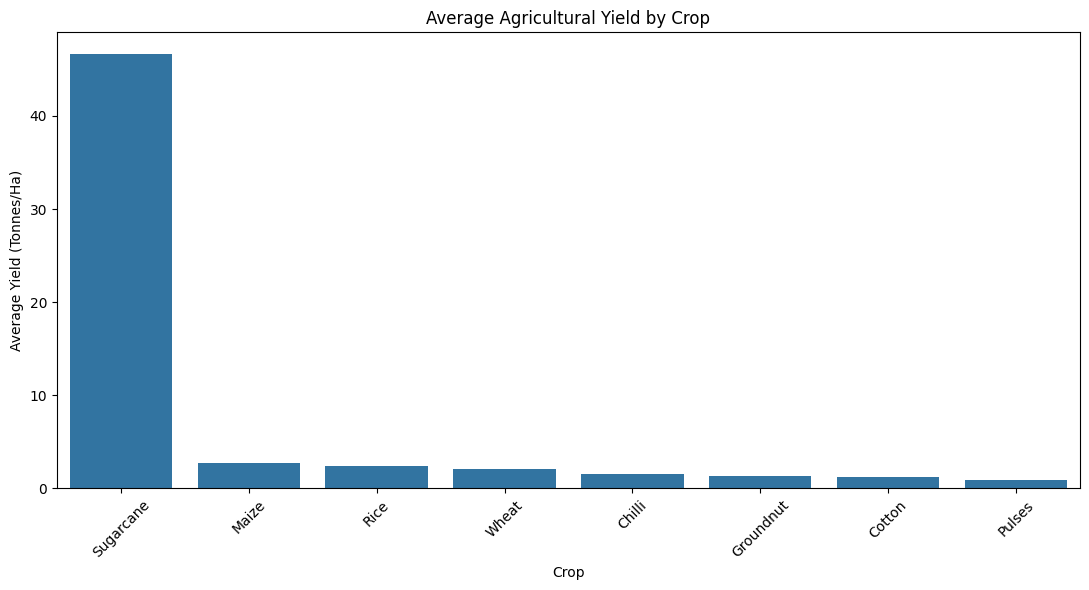

In [34]:
# ============================================================
# CELL 32: AVERAGE YIELD BY CROP
# ============================================================

# Create a bar chart showing the average yield
# of every crop.

plt.figure(figsize=(11, 6))

sns.barplot(
    data=crop_summary.reset_index(),
    x="Crop",
    y="Avg_Yield"
)

# Add title
plt.title("Average Agricultural Yield by Crop")

# Add axis labels
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")

# Rotate crop names so they are easier to read
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Display graph
plt.show()

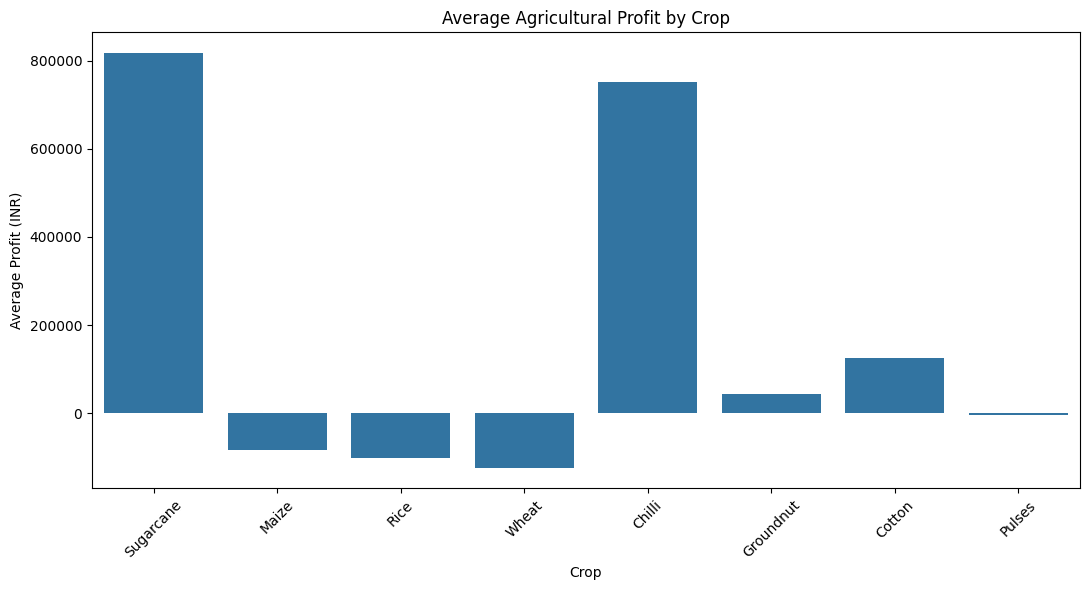

In [35]:
# ============================================================
# CELL 33: AVERAGE PROFIT BY CROP
# ============================================================

# Create a bar chart comparing the average profit
# generated by different crops.

plt.figure(figsize=(11, 6))

sns.barplot(
    data=crop_summary.reset_index(),
    x="Crop",
    y="Avg_Profit"
)

# Add title
plt.title("Average Agricultural Profit by Crop")

# Add axis labels
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")

# Rotate crop names
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Display graph
plt.show()

In [36]:
# ============================================================
# CELL 34: IRRIGATION METHOD ANALYSIS
# ============================================================

# Irrigation is an important agricultural factor.
# Different irrigation methods may be associated with
# differences in yield, profit and water usage.
#
# In this cell, we compare the major irrigation methods
# available in our dataset.

irrigation_summary = df.groupby(
    "Irrigation_Method"
).agg(

    # Number of agricultural records
    Farms=("Farm_ID", "count"),

    # Average crop yield
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),

    # Average profit
    Avg_Profit=("Profit_INR", "mean"),

    # Average amount of water used
    Avg_Water_Used=("Water_Used_m3", "mean"),

    # Average water efficiency
    Avg_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3",
        "mean"
    )

).sort_values(
    by="Avg_Yield",
    ascending=False
).round(2)

# Display the irrigation summary
display(irrigation_summary)

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.58,"219,626.00","5,918.75",6.27
Sprinkler,734,5.16,"91,121.08","6,208.26",4.67
Flood,1310,4.86,"73,354.02","8,026.47",3.44
Rainfed,1041,4.60,"79,050.37","3,549.55",7.56


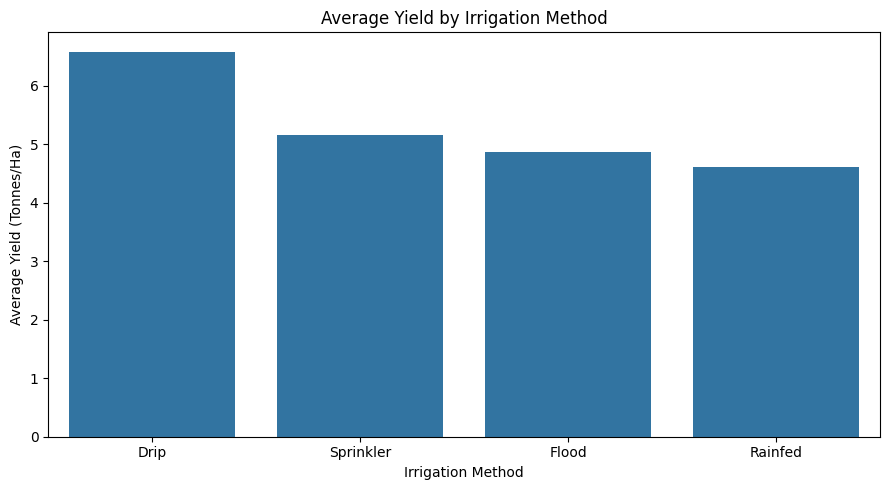

In [37]:
# ============================================================
# CELL 35: AVERAGE YIELD BY IRRIGATION METHOD
# ============================================================

# Create a bar chart to compare the average yield
# obtained under different irrigation methods.

plt.figure(figsize=(9, 5))

sns.barplot(
    data=irrigation_summary.reset_index(),
    x="Irrigation_Method",
    y="Avg_Yield"
)

# Add chart title
plt.title(
    "Average Yield by Irrigation Method"
)

# Add axis labels
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")

# Adjust spacing
plt.tight_layout()

# Display the graph
plt.show()

In [38]:
# ============================================================
# CELL 36: STATE-WISE AGRICULTURAL PERFORMANCE
# ============================================================

# Agriculture can vary across geographical regions.
# Therefore, we compare agricultural performance
# across different states.

state_summary = df.groupby("State").agg(

    # Number of records in each state
    Farms=("Farm_ID", "count"),

    # Average agricultural yield
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),

    # Average revenue
    Avg_Revenue=("Revenue_INR", "mean"),

    # Average profit
    Avg_Profit=("Profit_INR", "mean"),

    # Average disease/pest risk
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")

).sort_values(
    by="Avg_Profit",
    ascending=False
).round(2)

# Display state-wise results
display(state_summary)

,Farms,Avg_Yield,Avg_Revenue,Avg_Profit,Avg_Disease_Risk
State,,,,,
Punjab,484,6.12,"686,225.70","136,025.64",46.00
Maharashtra,512,5.02,"650,032.67","135,428.86",46.44
Karnataka,489,5.69,"653,426.18","119,422.34",46.06
Tamil Nadu,485,4.88,"629,093.42","117,744.75",46.28
Gujarat,488,5.66,"654,692.86","117,568.24",45.95
Telangana,516,5.04,"628,784.53","108,829.62",46.36
Madhya Pradesh,497,4.99,"597,558.36","86,840.76",47.08
Andhra Pradesh,529,4.63,"606,663.66","73,453.53",46.72


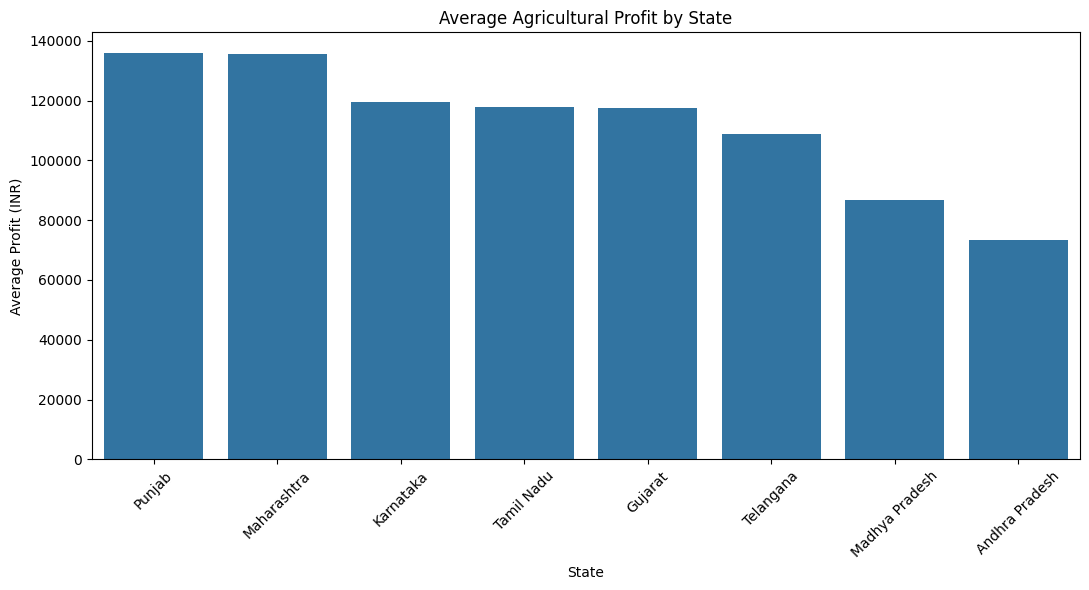

In [39]:
# ============================================================
# CELL 37: AVERAGE PROFIT BY STATE
# ============================================================

plt.figure(figsize=(11, 6))

sns.barplot(
    data=state_summary.reset_index(),
    x="State",
    y="Avg_Profit"
)

# Add title
plt.title(
    "Average Agricultural Profit by State"
)

# Add labels
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")

# Rotate state names for readability
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Display graph
plt.show()

In [40]:
# ============================================================
# CELL 38: CROP × SEASON YIELD ANALYSIS
# ============================================================

# A pivot table allows us to compare two categories at once.
#
# Rows    -> Crops
# Columns -> Seasons
# Values  -> Average Yield
#
# This helps us understand whether crop performance
# changes across different seasons.

crop_season = pd.pivot_table(
    df,

    # Variable whose average we want
    values="Yield_Tonnes_Ha",

    # Rows will contain crop names
    index="Crop",

    # Columns will contain seasons
    columns="Season",

    # Calculate average yield
    aggfunc="mean"
).round(2)

# Display the table
display(crop_season)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


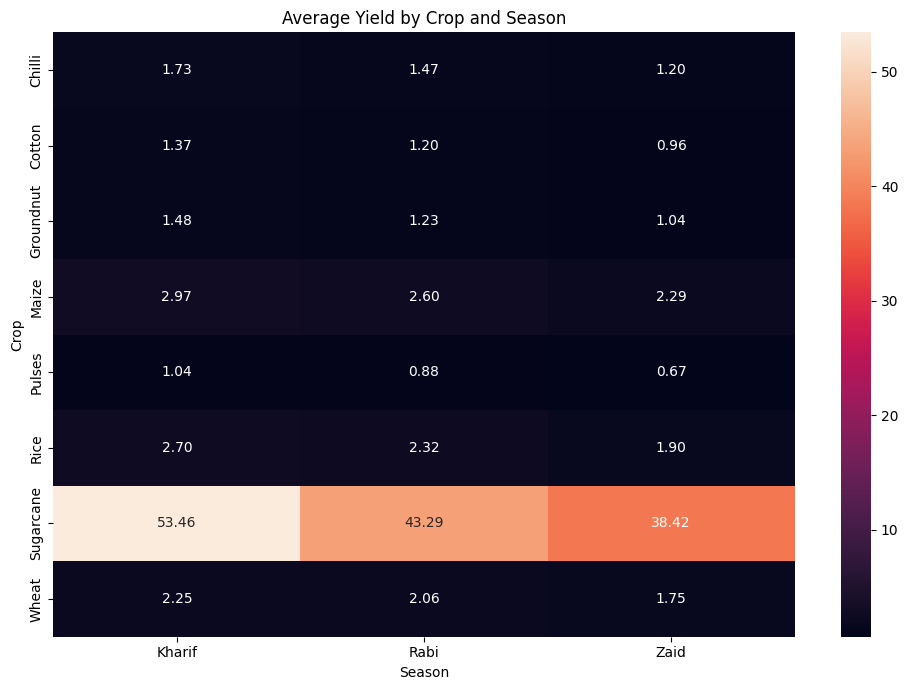

In [41]:
# ============================================================
# CELL 39: CROP × SEASON HEATMAP
# ============================================================

# A heatmap makes it easier to visually compare
# crop performance across seasons.

plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season,

    # Show numerical values inside each cell
    annot=True,

    # Display values with 2 decimal places
    fmt=".2f"
)

# Add title
plt.title(
    "Average Yield by Crop and Season"
)

# Add axis labels
plt.xlabel("Season")
plt.ylabel("Crop")

# Adjust layout
plt.tight_layout()

# Display the heatmap
plt.show()

In [42]:
# ============================================================
# CELL 40: IRRIGATION × SEASON YIELD ANALYSIS
# ============================================================

# Here we investigate whether the relationship between
# irrigation method and yield changes across seasons.

season_irrigation = pd.pivot_table(
    df,

    # We are comparing average yield
    values="Yield_Tonnes_Ha",

    # Rows represent irrigation methods
    index="Irrigation_Method",

    # Columns represent seasons
    columns="Season",

    # Calculate average yield
    aggfunc="mean"
).round(2)

# Display the result
display(season_irrigation)

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,7.26,6.11,5.85
Flood,4.98,5.06,3.98
Rainfed,5.70,3.93,3.06
Sprinkler,4.66,5.31,6.14


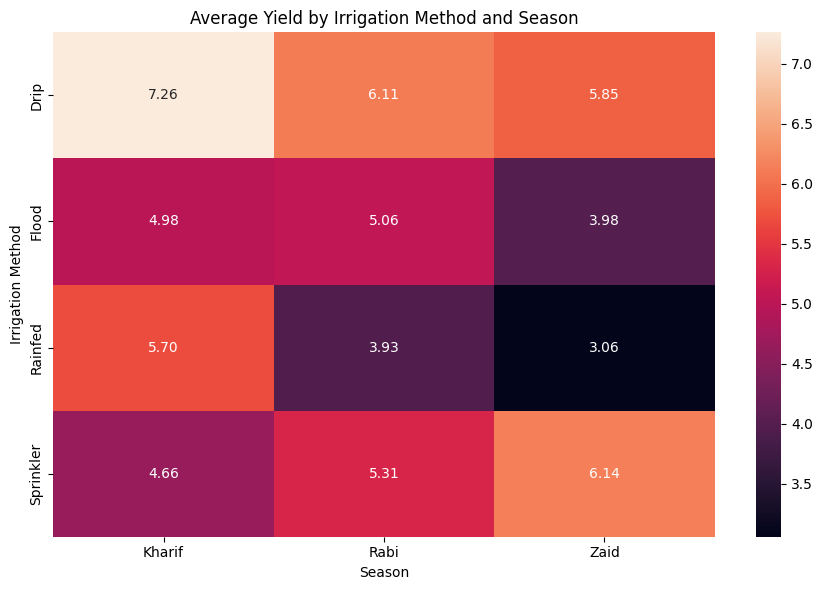

In [43]:
# ============================================================
# CELL 41: IRRIGATION × SEASON HEATMAP
# ============================================================

plt.figure(figsize=(9, 6))

sns.heatmap(
    season_irrigation,

    # Display values inside the cells
    annot=True,

    # Show 2 decimal places
    fmt=".2f"
)

plt.title(
    "Average Yield by Irrigation Method and Season"
)

plt.xlabel("Season")
plt.ylabel("Irrigation Method")

plt.tight_layout()
plt.show()

In [44]:
#Relationship/Correlation Analysis.
# ============================================================
# CELL 42: SELECT NUMERICAL VARIABLES FOR CORRELATION ANALYSIS
# ============================================================

# Correlation analysis is performed on numerical variables.
#
# Examples:
# Rainfall
# Temperature
# Soil moisture
# Yield
# Profit
# Water usage
#
# select_dtypes() selects all numerical columns from the dataset.

numeric_data = df.select_dtypes(
    include=np.number
)

# Display the numerical columns being used
print("Numerical variables used for correlation analysis:")

print(
    numeric_data.columns.tolist()
)

Numerical variables used for correlation analysis:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [45]:
# ============================================================
# CELL 43: CALCULATE CORRELATION MATRIX
# ============================================================

# The corr() function calculates the correlation
# between every pair of numerical variables.

correlation_matrix = numeric_data.corr()

# Display the complete correlation matrix
display(correlation_matrix)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,0.01,-0.01,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


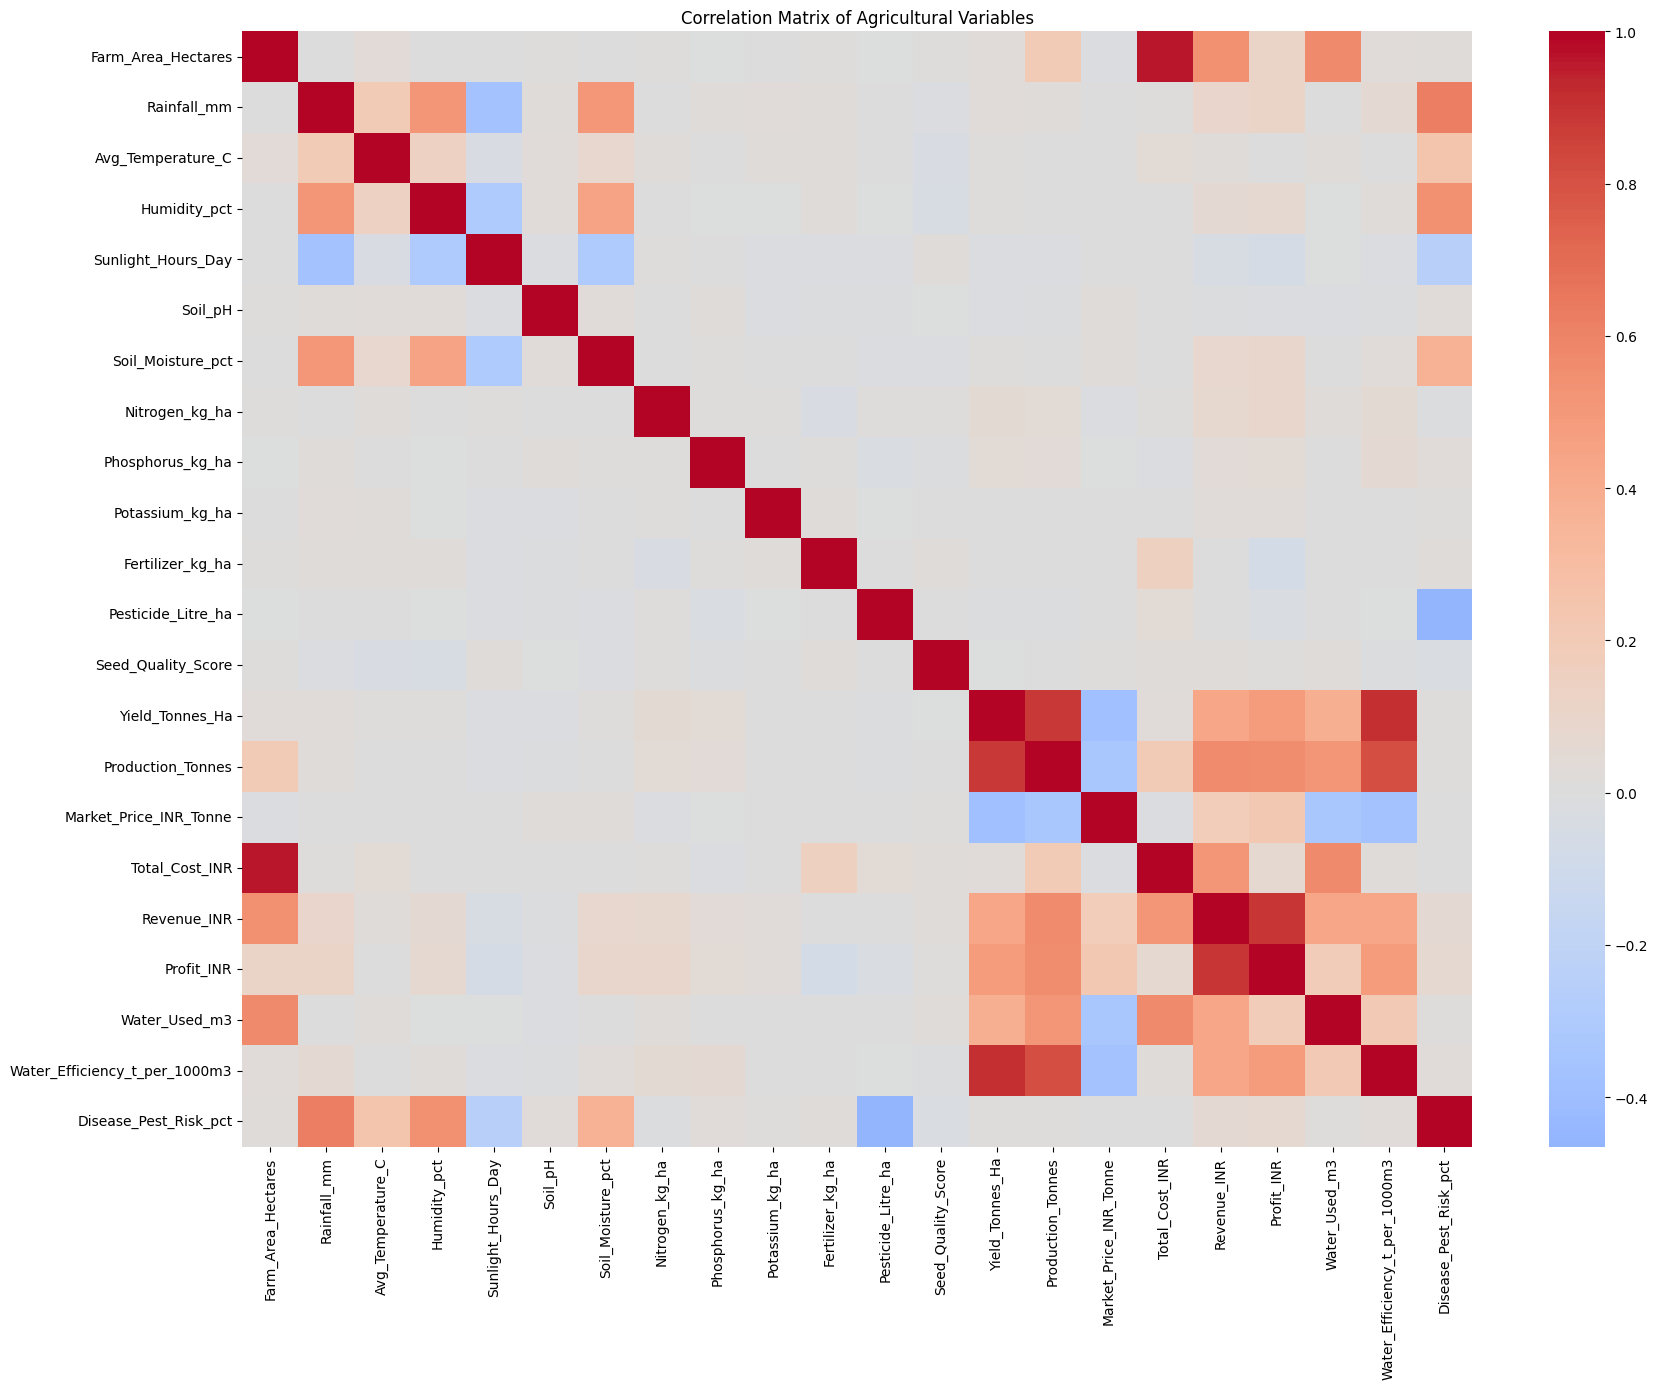

In [46]:
# ============================================================
# CELL 44: CORRELATION HEATMAP
# ============================================================

# A heatmap provides a visual representation of
# the correlation matrix.

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,

    # Use different shades to represent
    # positive and negative correlations
    cmap="coolwarm",

    # Center the colour scale around zero
    center=0
)

# Add title
plt.title(
    "Correlation Matrix of Agricultural Variables"
)

# Adjust layout
plt.tight_layout()

# Display the heatmap
plt.show()

In [47]:
# ============================================================
# CELL 45: CORRELATION OF VARIABLES WITH YIELD
# ============================================================

# Select the correlation values of every numerical variable
# with the Yield variable.

yield_correlation = (
    correlation_matrix[
        "Yield_Tonnes_Ha"
    ]
    .sort_values(
        ascending=False
    )
)

# Display the results
print(
    "Correlation of variables with Agricultural Yield:"
)

display(
    yield_correlation.to_frame(
        "Correlation with Yield"
    )
)

Correlation of variables with Agricultural Yield:


,Correlation with Yield
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03


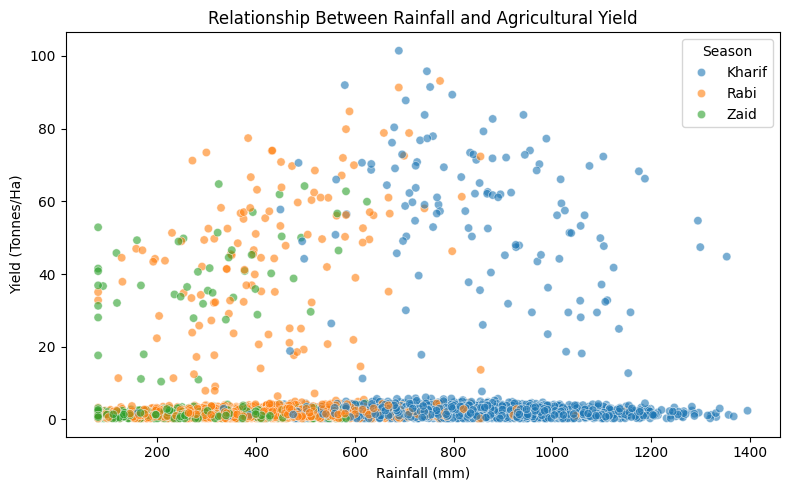

In [48]:
# ============================================================
# CELL 46: RELATIONSHIP BETWEEN RAINFALL AND YIELD
# ============================================================

# A scatter plot is used to study the relationship
# between rainfall and agricultural yield.

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,

    # X-axis = rainfall
    x="Rainfall_mm",

    # Y-axis = agricultural yield
    y="Yield_Tonnes_Ha",

    # Different seasons are shown separately
    hue="Season",

    # Make points slightly transparent
    alpha=0.6
)

# Add title
plt.title(
    "Relationship Between Rainfall and Agricultural Yield"
)

# Add axis labels
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

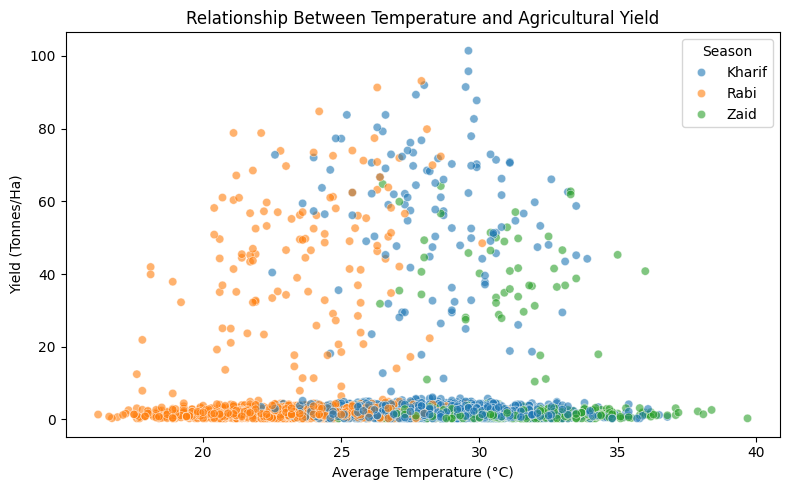

In [49]:
# ============================================================
# CELL 47: RELATIONSHIP BETWEEN TEMPERATURE AND YIELD
# ============================================================

# This scatter plot investigates whether
# temperature is associated with agricultural yield.

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,

    # X-axis = average temperature
    x="Avg_Temperature_C",

    # Y-axis = yield
    y="Yield_Tonnes_Ha",

    # Separate seasons using different markers/colours
    hue="Season",

    alpha=0.6
)

plt.title(
    "Relationship Between Temperature and Agricultural Yield"
)

plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

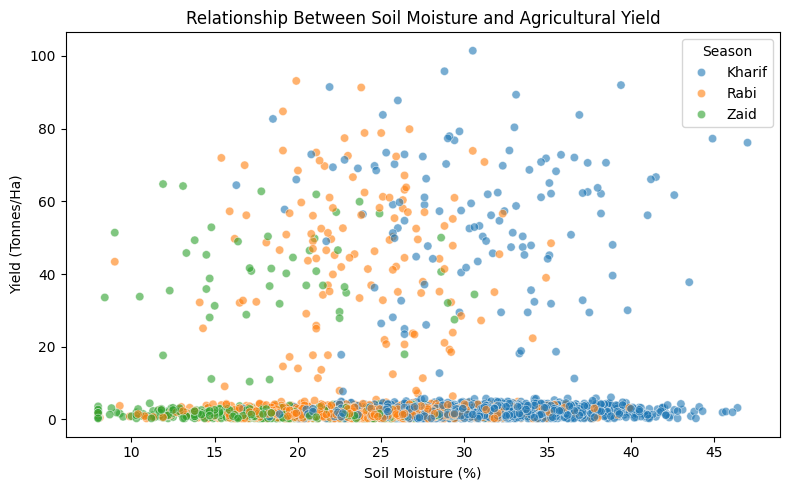

In [50]:
# ============================================================
# CELL 48: RELATIONSHIP BETWEEN SOIL MOISTURE AND YIELD
# ============================================================

# Soil moisture can be an important environmental
# condition for agricultural production.
#
# We investigate its relationship with yield.

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,

    # X-axis = soil moisture
    x="Soil_Moisture_pct",

    # Y-axis = yield
    y="Yield_Tonnes_Ha",

    # Display seasons separately
    hue="Season",

    alpha=0.6
)

plt.title(
    "Relationship Between Soil Moisture and Agricultural Yield"
)

plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

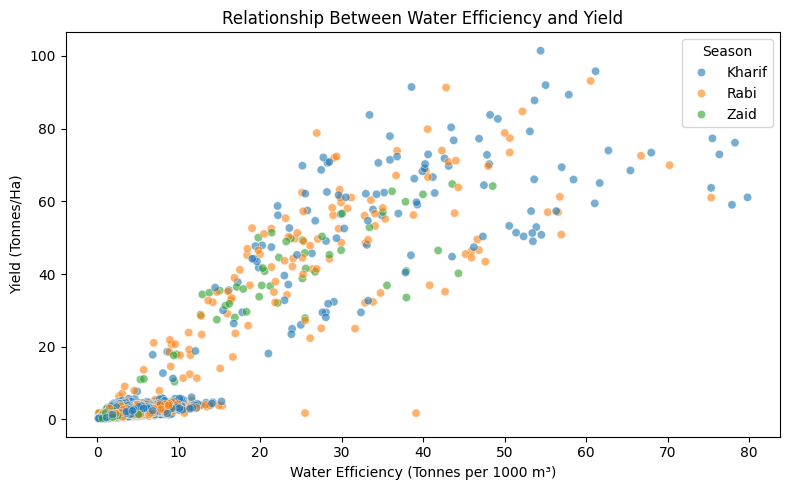

In [51]:
# ============================================================
# CELL 49: WATER EFFICIENCY VS YIELD
# ============================================================

# Water efficiency represents agricultural output
# obtained relative to the amount of water used.
#
# Here we investigate its relationship with yield.

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,

    # X-axis = water efficiency
    x="Water_Efficiency_t_per_1000m3",

    # Y-axis = yield
    y="Yield_Tonnes_Ha",

    # Separate observations by season
    hue="Season",

    alpha=0.6
)

plt.title(
    "Relationship Between Water Efficiency and Yield"
)

plt.xlabel(
    "Water Efficiency (Tonnes per 1000 m³)"
)

plt.ylabel(
    "Yield (Tonnes/Ha)"
)

plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# CELL 50: OUTLIER DETECTION USING IQR
# ============================================================
# IQR (Interquartile Range) is used to identify unusually
# high or low observations in numerical columns.
#
# Formula:
# IQR = Q3 - Q1
#
# Lower Limit = Q1 - 1.5 × IQR
# Upper Limit = Q3 + 1.5 × IQR
#
# IMPORTANT:
# We are ONLY identifying outliers here.
# We are NOT deleting them automatically.
# An unusual agricultural value may be a genuine observation.
# ============================================================

# Create an empty list to store the outlier results
outlier_results = []

# Check every numerical column
for column in numeric_cols:

    # Calculate the first quartile (25th percentile)
    Q1 = df[column].quantile(0.25)

    # Calculate the third quartile (75th percentile)
    Q3 = df[column].quantile(0.75)

    # Calculate Interquartile Range
    IQR = Q3 - Q1

    # Calculate lower boundary
    lower_limit = Q1 - 1.5 * IQR

    # Calculate upper boundary
    upper_limit = Q3 + 1.5 * IQR

    # Count values outside the lower and upper limits
    outlier_count = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ).sum()

    # Store the result
    outlier_results.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Potential Outliers": outlier_count
    })

# Convert results into a DataFrame
outlier_table = pd.DataFrame(outlier_results)

# Sort from highest number of outliers to lowest
outlier_table = outlier_table.sort_values(
    "Potential Outliers",
    ascending=False
)

# Display the table
display(outlier_table)

,Variable,Q1,Q3,IQR,Lower Limit,Upper Limit,Potential Outliers
18,Profit_INR,"-148,731.75","216,187.75","364,919.50","-696,111.00","763,567.00",404
14,Production_Tonnes,5.02,24.36,19.34,-23.98,53.36,333
20,Water_Efficiency_t_per_1000m3,1.66,5.15,3.49,-3.57,10.38,322
13,Yield_Tonnes_Ha,1.05,2.83,1.78,-1.62,5.50,302
19,Water_Used_m3,"2,268.75","7,829.75","5,561.00","-6,072.75","16,171.25",276
17,Revenue_INR,"207,517.25","836,874.75","629,357.50","-736,519.00","1,780,911.00",240
9,Potassium_kg_ha,86.20,123.60,37.40,30.10,179.70,32
4,Sunlight_Hours_Day,6.60,8.10,1.50,4.35,10.35,26
8,Phosphorus_kg_ha,46.20,69.40,23.20,11.40,104.20,16
10,Fertilizer_kg_ha,143.97,227.20,83.22,19.14,352.04,15


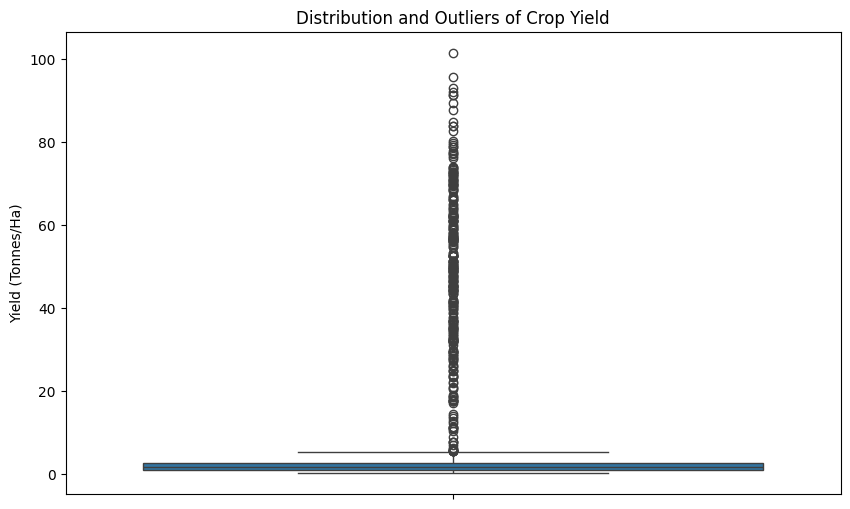

In [53]:
# ============================================================
# CELL 51: YIELD DISTRIBUTION AND OUTLIERS
# ============================================================
# A boxplot helps us visually identify the distribution of
# crop yield and any observations that lie far from the
# normal range.
# ============================================================

plt.figure(figsize=(10, 6))

# Create boxplot for Yield
sns.boxplot(y=df["Yield_Tonnes_Ha"])

# Add title
plt.title("Distribution and Outliers of Crop Yield")

# Label the y-axis
plt.ylabel("Yield (Tonnes/Ha)")

# Display the graph
plt.show()

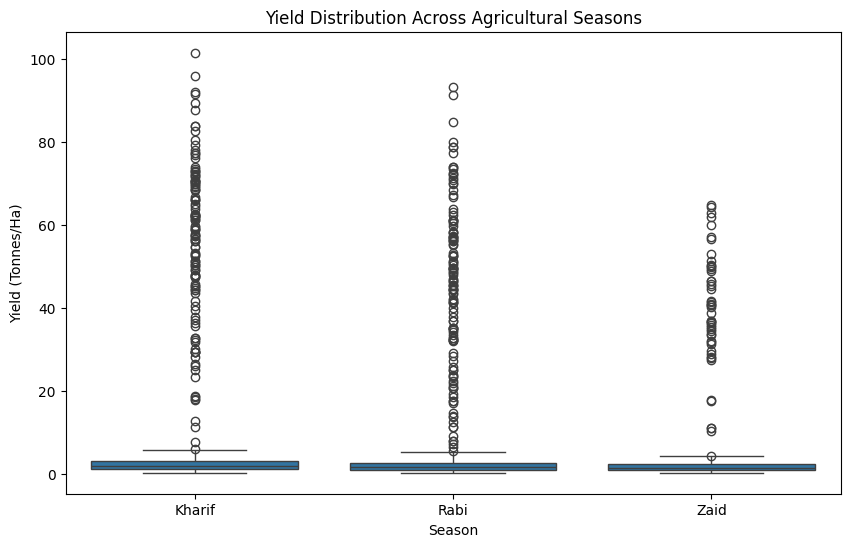

In [54]:
# ============================================================
# CELL 52: SEASON-WISE YIELD DISTRIBUTION
# ============================================================
# This boxplot compares the distribution of yield among
# Kharif, Rabi and Zaid seasons.
# ============================================================

plt.figure(figsize=(10, 6))

# Create boxplot grouped by season
sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

# Add title
plt.title("Yield Distribution Across Agricultural Seasons")

# Label axes
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

# Display graph
plt.show()

In [55]:
# ============================================================
# CELL 53: PROFIT MARGIN CALCULATION
# ============================================================
# Profit Margin tells us what percentage of revenue remains
# as profit after considering the total cost.
#
# Formula:
# Profit Margin (%) = (Profit / Revenue) × 100
# ============================================================

# Calculate profit margin percentage
df["Profit_Margin_pct"] = (
    df["Profit_INR"] / df["Revenue_INR"]
) * 100

# Display selected columns
display(
    df[
        [
            "Farm_ID",
            "Season",
            "Revenue_INR",
            "Total_Cost_INR",
            "Profit_INR",
            "Profit_Margin_pct"
        ]
    ].head(10)
)

,Farm_ID,Season,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct
0,SF10001,Kharif,30810,42662,-11852,-38.47
1,SF10002,Kharif,40401,492351,-451950,"-1,118.66"
2,SF10003,Rabi,190466,315210,-124744,-65.49
3,SF10004,Kharif,200740,296444,-95704,-47.68
4,SF10005,Zaid,193607,337959,-144352,-74.56
5,SF10006,Zaid,269570,302333,-32763,-12.15
6,SF10007,Rabi,472102,513341,-41239,-8.74
7,SF10008,Kharif,441265,436200,5065,1.15
8,SF10009,Zaid,755834,525129,230705,30.52
9,SF10010,Rabi,2958907,1004072,1954835,66.07


In [56]:
# ============================================================
# CELL 54: PROFITABILITY BY SEASON
# ============================================================
# This analysis compares economic performance across
# Kharif, Rabi and Zaid seasons.
# ============================================================

season_profitability = (
    df.groupby("Season")
    .agg(
        Average_Revenue_INR=("Revenue_INR", "mean"),
        Average_Cost_INR=("Total_Cost_INR", "mean"),
        Average_Profit_INR=("Profit_INR", "mean"),
        Average_Profit_Margin_pct=("Profit_Margin_pct", "mean")
    )
    .reset_index()
)

# Round numerical values for readability
season_profitability = season_profitability.round(2)

# Display result
display(season_profitability)

,Season,Average_Revenue_INR,Average_Cost_INR,Average_Profit_INR,Average_Profit_Margin_pct
0,Kharif,"710,719.06","531,804.41","178,914.65",-38.64
1,Rabi,"601,526.05","513,836.58","87,689.47",-44.27
2,Zaid,"519,171.90","543,976.73","-24,804.82",-69.35


In [57]:
# ============================================================
# CELL 55: PROFITABLE VS LOSS-MAKING FARMS
# ============================================================
# We classify farms into two groups:
#
# Profit > 0  → Profitable
# Profit <= 0 → Not Profitable
# ============================================================

# Create a new categorical column
df["Profitable"] = np.where(
    df["Profit_INR"] > 0,
    "Profitable",
    "Not Profitable"
)

# Calculate percentage of each group
profit_status = (
    df["Profitable"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

# Rename columns
profit_status.columns = [
    "Profit Status",
    "Percentage"
]

# Display result
display(profit_status)

,Profit Status,Percentage
0,Profitable,50.85
1,Not Profitable,49.15


In [59]:
# ============================================================
# CELL 56: WATER EFFICIENCY BY SEASON
# ============================================================
# Water efficiency tells us how effectively water is being
# converted into agricultural output.
#
# Higher water efficiency = better utilization of water.
# ============================================================

water_efficiency_season = (
    df.groupby("Season")
    .agg(
        Average_Water_Used_m3=("Water_Used_m3", "mean"),
        Average_Water_Efficiency=(
            "Water_Efficiency_t_per_1000m3",
            "mean"
        )
    )
    .reset_index()
)

# Round values for easy reading
water_efficiency_season = water_efficiency_season.round(2)

# Display the result
display(water_efficiency_season)

,Season,Average_Water_Used_m3,Average_Water_Efficiency
0,Kharif,"6,102.20",5.89
1,Rabi,"5,846.99",5.19
2,Zaid,"6,419.89",4.41


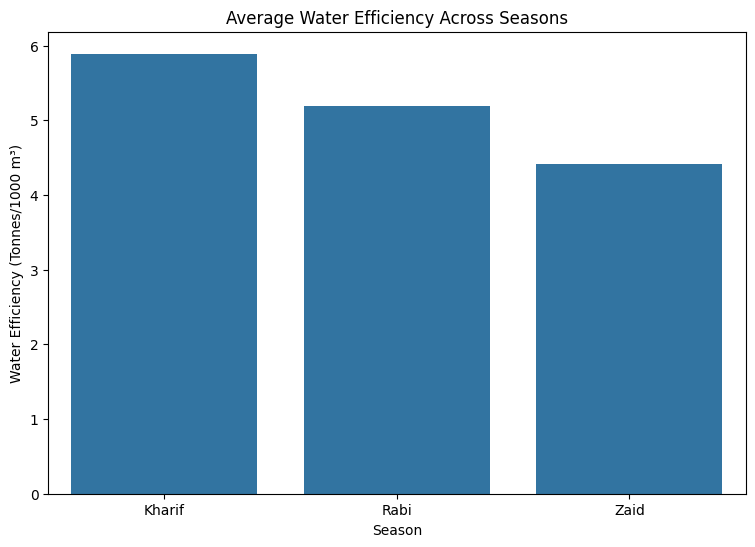

In [60]:
# ============================================================
# CELL 57: WATER EFFICIENCY VISUALIZATION
# ============================================================
# A bar chart makes it easier to compare water efficiency
# between different agricultural seasons.
# ============================================================

plt.figure(figsize=(9, 6))

# Create bar chart
sns.barplot(
    data=water_efficiency_season,
    x="Season",
    y="Average_Water_Efficiency"
)

# Add title
plt.title("Average Water Efficiency Across Seasons")

# Label axes
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes/1000 m³)")

# Display the graph
plt.show()

In [61]:
# ============================================================
# CELL 58: DISEASE AND PEST RISK BY SEASON
# ============================================================
# This analysis compares the average disease/pest risk
# across agricultural seasons.
# ============================================================

disease_risk_season = (
    df.groupby("Season")
    .agg(
        Average_Disease_Pest_Risk_pct=(
            "Disease_Pest_Risk_pct",
            "mean"
        )
    )
    .reset_index()
)

# Round the values
disease_risk_season = disease_risk_season.round(2)

# Display result
display(disease_risk_season)

,Season,Average_Disease_Pest_Risk_pct
0,Kharif,54.47
1,Rabi,40.48
2,Zaid,38.22


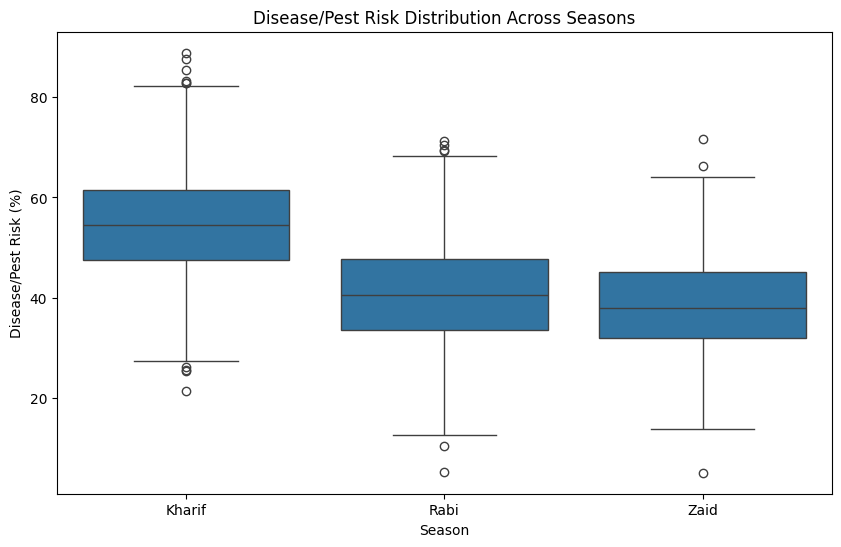

In [62]:
# ============================================================
# CELL 59: DISEASE/PEST RISK DISTRIBUTION BY SEASON
# ============================================================
# This boxplot shows the spread and variation of disease/pest
# risk within each season.
# ============================================================

plt.figure(figsize=(10, 6))

# Create boxplot
sns.boxplot(
    data=df,
    x="Season",
    y="Disease_Pest_Risk_pct"
)

# Add title
plt.title("Disease/Pest Risk Distribution Across Seasons")

# Label axes
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")

# Display graph
plt.show()

In [63]:
# ============================================================
# CELL 60: ONE-WAY ANOVA FOR SEASONAL COMPARISON
# ============================================================
# ANOVA = Analysis of Variance
#
# It tests whether the mean values of multiple groups
# are significantly different.
#
# Here, we compare:
# Kharif vs Rabi vs Zaid
#
# We test three important performance measures:
# 1. Yield
# 2. Profit
# 3. Water Efficiency
#
# Hypotheses:
#
# H0 (Null Hypothesis):
# The seasonal means are equal.
#
# H1 (Alternative Hypothesis):
# At least one seasonal mean is different.
#
# If p-value < 0.05:
# → statistically significant difference
#
# If p-value >= 0.05:
# → statistically significant difference is not established.
# ============================================================

from scipy.stats import f_oneway

# ------------------------------------------------------------
# 1. ANOVA FOR YIELD
# ------------------------------------------------------------

yield_kharif = df[df["Season"] == "Kharif"]["Yield_Tonnes_Ha"]
yield_rabi = df[df["Season"] == "Rabi"]["Yield_Tonnes_Ha"]
yield_zaid = df[df["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

yield_f, yield_p = f_oneway(
    yield_kharif,
    yield_rabi,
    yield_zaid
)

# ------------------------------------------------------------
# 2. ANOVA FOR PROFIT
# ------------------------------------------------------------

profit_kharif = df[df["Season"] == "Kharif"]["Profit_INR"]
profit_rabi = df[df["Season"] == "Rabi"]["Profit_INR"]
profit_zaid = df[df["Season"] == "Zaid"]["Profit_INR"]

profit_f, profit_p = f_oneway(
    profit_kharif,
    profit_rabi,
    profit_zaid
)

# ------------------------------------------------------------
# 3. ANOVA FOR WATER EFFICIENCY
# ------------------------------------------------------------

water_kharif = df[
    df["Season"] == "Kharif"
]["Water_Efficiency_t_per_1000m3"]

water_rabi = df[
    df["Season"] == "Rabi"
]["Water_Efficiency_t_per_1000m3"]

water_zaid = df[
    df["Season"] == "Zaid"
]["Water_Efficiency_t_per_1000m3"]

water_f, water_p = f_oneway(
    water_kharif,
    water_rabi,
    water_zaid
)

# ------------------------------------------------------------
# CREATE A SUMMARY TABLE
# ------------------------------------------------------------

anova_results = pd.DataFrame({
    "Variable": [
        "Yield",
        "Profit",
        "Water Efficiency"
    ],
    "F-statistic": [
        yield_f,
        profit_f,
        water_f
    ],
    "p-value": [
        yield_p,
        profit_p,
        water_p
    ]
})

# Round values
anova_results["F-statistic"] = anova_results["F-statistic"].round(3)
anova_results["p-value"] = anova_results["p-value"].round(4)

# Add interpretation
anova_results["Significant (p < 0.05)"] = (
    anova_results["p-value"] < 0.05
)

# Display
display(anova_results)

,Variable,F-statistic,p-value,Significant (p < 0.05)
0,Yield,1.54,0.21,False
1,Profit,34.29,0.00,True
2,Water Efficiency,6.95,0.00,True


In [64]:
# ============================================================
# CELL 61: PAIRWISE WELCH T-TEST FOR SEASONAL YIELD
# ============================================================
# ANOVA tells us whether there is an overall difference
# somewhere among the three seasons.
#
# Pairwise t-tests compare seasons two at a time:
#
# Kharif vs Rabi
# Kharif vs Zaid
# Rabi vs Zaid
#
# Welch's t-test is used because it does not require equal
# variance between the two groups.
# ============================================================

from scipy.stats import ttest_ind

# Store the season names
seasons = ["Kharif", "Rabi", "Zaid"]

# Empty list for results
pairwise_results = []

# Compare every pair of seasons
for i in range(len(seasons)):

    for j in range(i + 1, len(seasons)):

        season1 = seasons[i]
        season2 = seasons[j]

        # Extract yield values
        group1 = df[
            df["Season"] == season1
        ]["Yield_Tonnes_Ha"]

        group2 = df[
            df["Season"] == season2
        ]["Yield_Tonnes_Ha"]

        # Perform Welch's t-test
        t_stat, p_value = ttest_ind(
            group1,
            group2,
            equal_var=False
        )

        # Store result
        pairwise_results.append({
            "Comparison": f"{season1} vs {season2}",
            "t-statistic": round(t_stat, 3),
            "p-value": round(p_value, 4),
            "Significant (p < 0.05)": p_value < 0.05
        })

# Convert into DataFrame
pairwise_yield_results = pd.DataFrame(pairwise_results)

# Display results
display(pairwise_yield_results)

,Comparison,t-statistic,p-value,Significant (p < 0.05)
0,Kharif vs Rabi,1.27,0.21,False
1,Kharif vs Zaid,1.72,0.09,False
2,Rabi vs Zaid,0.71,0.48,False


In [65]:
# ============================================================
# CELL 62: KEY FINDINGS FROM THE ANALYSIS
# ============================================================
# This cell automatically extracts important findings from
# the analysis performed so far.
#
# These findings can later be used in:
# - Project report
# - PPT presentation
# - Viva
# - Final conclusion
# ============================================================

# ------------------------------------------------------------
# FIND THE BEST SEASON FOR DIFFERENT PERFORMANCE MEASURES
# ------------------------------------------------------------

# Season with highest average yield
best_yield_season = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .idxmax()
)

# Season with highest average profit
best_profit_season = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .idxmax()
)

# Season with highest water efficiency
best_water_season = (
    df.groupby("Season")["Water_Efficiency_t_per_1000m3"]
    .mean()
    .idxmax()
)

# Season with highest disease/pest risk
highest_risk_season = (
    df.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .idxmax()
)

# ------------------------------------------------------------
# DISPLAY FINDINGS
# ------------------------------------------------------------

print("KEY FINDINGS")
print("=" * 60)

print(
    f"1. The season with the highest average yield is: "
    f"{best_yield_season}"
)

print(
    f"2. The season with the highest average profit is: "
    f"{best_profit_season}"
)

print(
    f"3. The season with the highest average water efficiency is: "
    f"{best_water_season}"
)

print(
    f"4. The season with the highest average disease/pest risk is: "
    f"{highest_risk_season}"
)

print("=" * 60)

KEY FINDINGS
1. The season with the highest average yield is: Kharif
2. The season with the highest average profit is: Kharif
3. The season with the highest average water efficiency is: Kharif
4. The season with the highest average disease/pest risk is: Kharif


In [66]:
# ============================================================
# CELL 63: STATISTICAL FINDINGS
# ============================================================
# This cell converts our statistical tests into simple
# conclusions that can be used in the project report.
# ============================================================

print("STATISTICAL FINDINGS")
print("=" * 60)

# Check Yield ANOVA result
if yield_p < 0.05:
    print(
        "• Seasonal differences in yield are statistically significant."
    )
else:
    print(
        "• Seasonal differences in yield are NOT statistically "
        "significant at the 5% significance level."
    )

# Check Profit ANOVA result
if profit_p < 0.05:
    print(
        "• Seasonal differences in profit are statistically significant."
    )
else:
    print(
        "• Seasonal differences in profit are NOT statistically significant."
    )

# Check Water Efficiency ANOVA result
if water_p < 0.05:
    print(
        "• Seasonal differences in water efficiency are "
        "statistically significant."
    )
else:
    print(
        "• Seasonal differences in water efficiency are NOT "
        "statistically significant."
    )

print("=" * 60)

STATISTICAL FINDINGS
• Seasonal differences in yield are NOT statistically significant at the 5% significance level.
• Seasonal differences in profit are statistically significant.
• Seasonal differences in water efficiency are statistically significant.


In [67]:
# ============================================================
# CELL 64: RECOMMENDATIONS
# ============================================================
# Based on the descriptive analysis, visualizations and
# statistical tests, we provide practical recommendations.
#
# These recommendations connect the data analysis with
# agricultural planning and decision-making.
# ============================================================

print("RECOMMENDATIONS")
print("=" * 70)

print("""
1. SEASONAL PLANNING
   Agricultural planning should consider seasonal differences
   in rainfall, temperature, humidity, soil moisture and other
   environmental conditions.

2. RESOURCE MANAGEMENT
   Water usage should be managed carefully because water
   efficiency varies across seasons.

3. IRRIGATION MANAGEMENT
   More efficient irrigation practices should be considered
   where appropriate to improve water utilization.

4. PROFITABILITY MANAGEMENT
   Farmers and planners should consider production costs,
   market prices and expected revenue when selecting crops
   and planning seasonal activities.

5. DISEASE AND PEST MANAGEMENT
   Seasons with higher disease/pest risk should receive
   increased monitoring and preventive management.

6. REGIONAL PLANNING
   Differences between states, districts and agricultural
   categories should be considered when making region-specific
   decisions.

7. DATA-DRIVEN DECISION MAKING
   Historical agricultural data should be continuously analyzed
   to identify changing patterns and support evidence-based
   planning.
""")

RECOMMENDATIONS

1. SEASONAL PLANNING
   Agricultural planning should consider seasonal differences
   in rainfall, temperature, humidity, soil moisture and other
   environmental conditions.

2. RESOURCE MANAGEMENT
   Water usage should be managed carefully because water
   efficiency varies across seasons.

3. IRRIGATION MANAGEMENT
   More efficient irrigation practices should be considered
   where appropriate to improve water utilization.

4. PROFITABILITY MANAGEMENT
   Farmers and planners should consider production costs,
   market prices and expected revenue when selecting crops
   and planning seasonal activities.

5. DISEASE AND PEST MANAGEMENT
   Seasons with higher disease/pest risk should receive
   increased monitoring and preventive management.

6. REGIONAL PLANNING
   Differences between states, districts and agricultural
   categories should be considered when making region-specific
   decisions.

7. DATA-DRIVEN DECISION MAKING
   Historical agricultural data should be 

In [68]:
# ============================================================
# CELL 65: FINAL PROJECT CONCLUSION
# ============================================================
# This cell presents the overall conclusion of the complete
# Seasonal Agriculture Performance Analysis.
# ============================================================

print("=" * 80)
print("FINAL PROJECT CONCLUSION")
print("=" * 80)

print("""
The Seasonal Agriculture Performance Analysis provided a
systematic understanding of agricultural performance across
Kharif, Rabi and Zaid seasons.

The analysis examined environmental conditions, crop yield,
production, resource utilization, profitability, irrigation
practices and disease/pest risk.

Kharif showed the highest average yield, profit and water
efficiency among the three seasons in the analyzed dataset.
However, statistical testing showed that the difference in
average yield between seasons was not statistically significant
at the 5% significance level.

In contrast, seasonal differences in profit were statistically
significant. Water efficiency also showed statistically
significant differences across seasons.

The analysis also showed that environmental conditions such as
rainfall, temperature, humidity and soil moisture vary across
seasons. These variations provide useful context for
understanding agricultural performance.

Crop-wise and irrigation-wise comparisons further revealed
differences in productivity, profitability and resource
utilization.

Disease and pest risk also varied across seasons, highlighting
the importance of seasonal monitoring and preventive management.

Overall, the project demonstrates how data analysis,
visualization and statistical techniques can be used to identify
agricultural patterns, compare seasonal performance, understand
resource utilization and support evidence-based agricultural
planning.

The findings can help farmers, agricultural planners and other
stakeholders make more informed decisions regarding crop
selection, resource management, irrigation and seasonal
planning.
""")

print("=" * 80)
print("END OF ANALYSIS")
print("=" * 80)

FINAL PROJECT CONCLUSION

The Seasonal Agriculture Performance Analysis provided a
systematic understanding of agricultural performance across
Kharif, Rabi and Zaid seasons.

The analysis examined environmental conditions, crop yield,
production, resource utilization, profitability, irrigation
practices and disease/pest risk.

Kharif showed the highest average yield, profit and water
efficiency among the three seasons in the analyzed dataset.
However, statistical testing showed that the difference in
average yield between seasons was not statistically significant
at the 5% significance level.

In contrast, seasonal differences in profit were statistically
significant. Water efficiency also showed statistically
significant differences across seasons.

The analysis also showed that environmental conditions such as
rainfall, temperature, humidity and soil moisture vary across
seasons. These variations provide useful context for
understanding agricultural performance.

Crop-wise and irriga